# Notebook 03: YOLOv8 Training & Evaluation

This notebook trains a **YOLOv8** object detection model for PCB defect detection using transfer learning from COCO-pretrained weights.

**Designed for Google Colab with GPU runtime** (T4 16GB VRAM recommended).

**Pipeline:**
1. Load pretrained YOLOv8n (nano) — 3.2M parameters
2. Fine-tune on the Kaggle PCB Defects dataset (6 classes)
3. Evaluate with mAP, precision, recall, per-class metrics
4. Visualize training curves, predictions, and confusion matrix
5. Save best model for downstream notebooks

In [1]:
# Colab setup (uncomment when running on Colab)
# from google.colab import drive
# drive.mount('/content/drive')
# !pip install -q ultralytics

import shutil
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from ultralytics import YOLO

# Paths — update for Colab if needed
DATASET_YAML = Path("../data/pcb-yolo/dataset.yaml")
PROJECT_DIR = Path("../models")
PROJECT_DIR.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = {
    0: "missing_hole", 1: "mouse_bite", 2: "open_circuit",
    3: "short", 4: "spur", 5: "spurious_copper",
}

print(f"Dataset config: {DATASET_YAML}")

Dataset config: ../data/pcb-yolo/dataset.yaml


## 1. Load Pretrained YOLOv8

We start with **YOLOv8n** (nano, 3.2M params) pretrained on COCO for fast iteration. If mAP@0.5 < 0.70, we can upgrade to YOLOv8s (11.2M params).

In [2]:
# Load YOLOv8n pretrained on COCO
model = YOLO("yolov8n.pt")
print(f"Model loaded: YOLOv8n")
print(f"Parameters: {sum(p.numel() for p in model.model.parameters()):,}")

Model loaded: YOLOv8n
Parameters: 3,157,200


## 2. Training Configuration

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| `epochs` | 100 | Sufficient for convergence with early stopping |
| `patience` | 10 | Stop if no improvement for 10 epochs |
| `imgsz` | 640 | YOLOv8 default — good balance of detail vs memory |
| `batch` | 16 | Sized for Colab T4 (16GB VRAM) — reduce to 8 if OOM |
| `optimizer` | AdamW | Better generalization than SGD for fine-tuning |
| `lr0` | 0.01 | Default Ultralytics learning rate |
| `flipud` | 0.5 | PCBs have no "up" — enable vertical flip |
| `degrees` | 90 | PCBs can be rotated — enable rotation |
| `mosaic` | 1.0 | Helps with small defect detection |

In [3]:
# Train YOLOv8 on PCB defect dataset
# Skip training if results already exist (e.g., from a previous run)
results_csv_check = PROJECT_DIR / "yolov8_pcb" / "results.csv"

if results_csv_check.exists():
    print(f"Training results already exist at {results_csv_check} — skipping training")
    print(f"Delete {PROJECT_DIR / 'yolov8_pcb'} to retrain from scratch")
else:
    # For Colab: set project to Google Drive path to survive disconnects
    # COLAB_PROJECT = "/content/drive/MyDrive/pcb-training"
    # For local: use ../models
    train_project = str(PROJECT_DIR)

    results = model.train(
        data=str(DATASET_YAML),
        epochs=100,
        patience=10,
        imgsz=640,
        batch=16,
        optimizer="AdamW",
        lr0=0.01,
        # Augmentation tuned for PCB images
        flipud=0.5,
        degrees=90.0,
        mosaic=1.0,
        # Checkpointing — on Colab, change to COLAB_PROJECT for Drive persistence
        project=train_project,
        name="yolov8_pcb",
        save=True,
        save_period=10,
        exist_ok=True,
        # Uncomment to resume interrupted training (especially useful on Colab):
        # resume=True,
    )

Training results already exist at ../models/yolov8_pcb/results.csv — skipping training
Delete ../models/yolov8_pcb to retrain from scratch


## 3. Training Curves

We plot loss curves and validation metrics across epochs to verify convergence and check for overfitting.

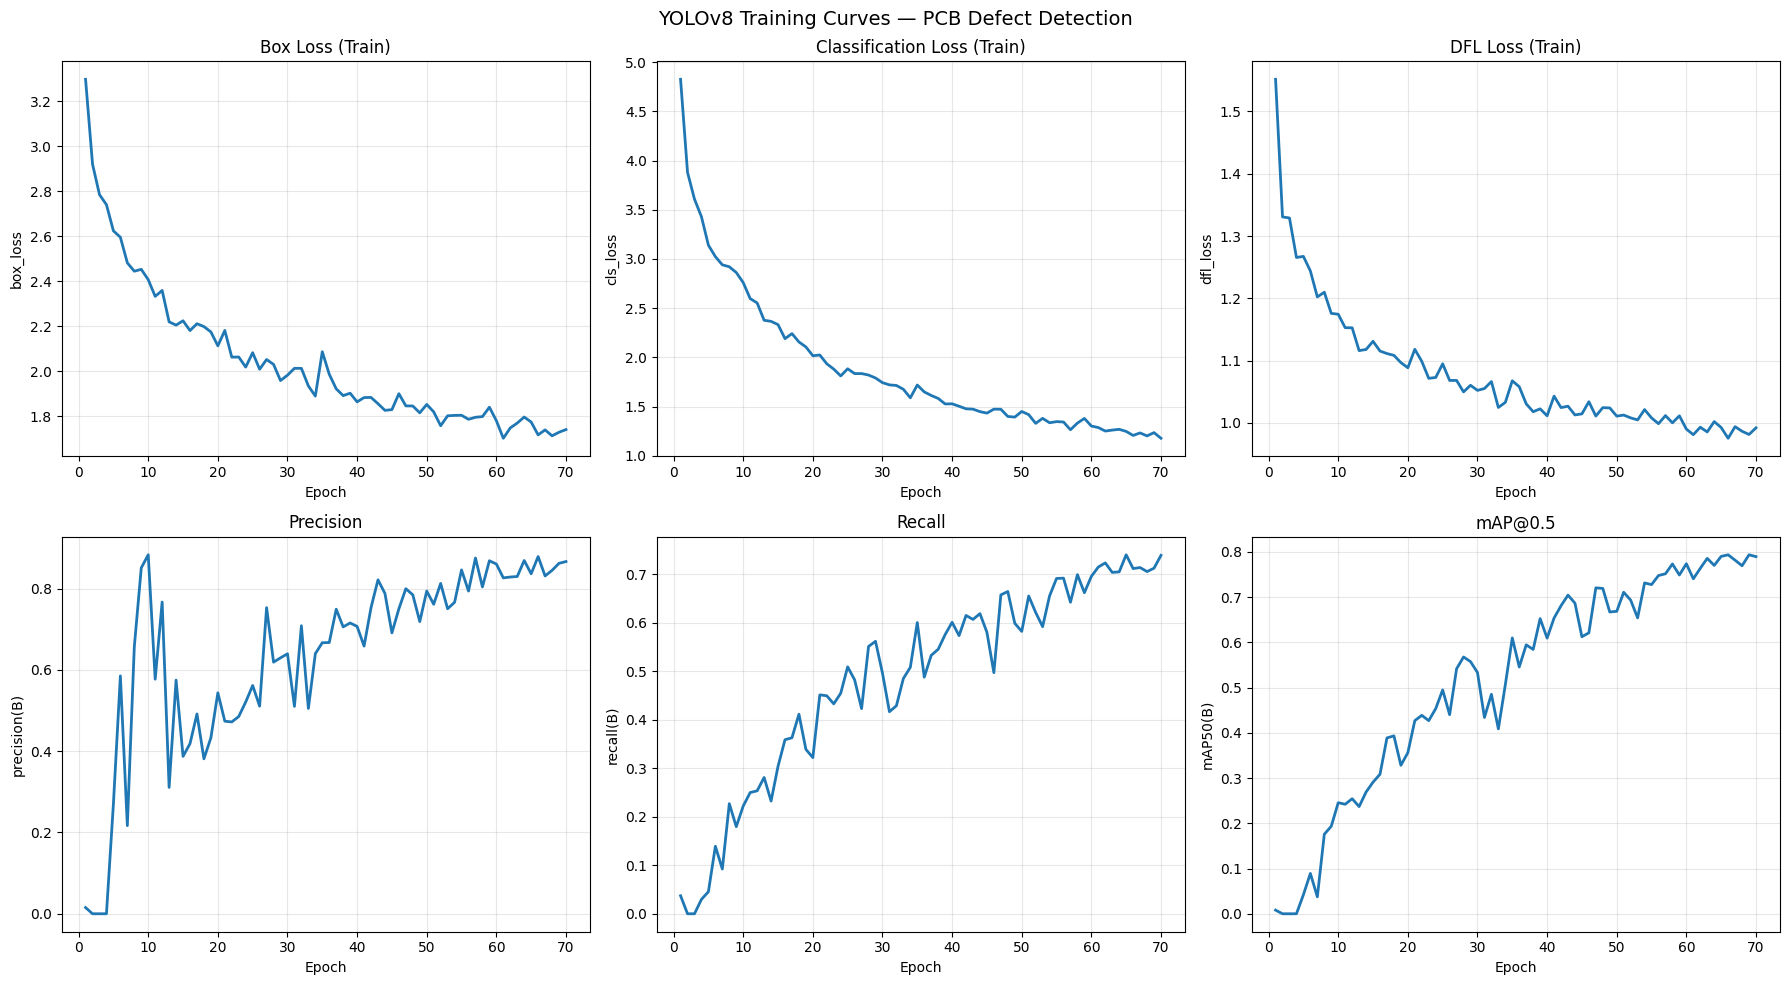

In [4]:
# Plot training curves from results CSV
results_csv = PROJECT_DIR / "yolov8_pcb" / "results.csv"

if results_csv.exists():
    df = pd.read_csv(results_csv)
    df.columns = df.columns.str.strip()

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    metrics = [
        ("train/box_loss", "Box Loss (Train)"),
        ("train/cls_loss", "Classification Loss (Train)"),
        ("train/dfl_loss", "DFL Loss (Train)"),
        ("metrics/precision(B)", "Precision"),
        ("metrics/recall(B)", "Recall"),
        ("metrics/mAP50(B)", "mAP@0.5"),
    ]

    for ax, (col, title) in zip(axes.flat, metrics):
        if col in df.columns:
            ax.plot(df["epoch"], df[col], linewidth=2)
            ax.set_xlabel("Epoch")
            ax.set_ylabel(col.split("/")[-1])
            ax.set_title(title)
            ax.grid(True, alpha=0.3)

    plt.suptitle("YOLOv8 Training Curves — PCB Defect Detection", fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print(f"Results not found at {results_csv} — complete training first")

## 4. Validation Evaluation

Run the best model on the held-out test split and report mAP, precision, recall, and per-class AP.

In [5]:
# Evaluate best model on test set
best_model_path = PROJECT_DIR / "yolov8_pcb" / "weights" / "best.pt"

if best_model_path.exists():
    best_model = YOLO(str(best_model_path))
    val_results = best_model.val(data=str(DATASET_YAML), split="test")

    print("=== Test Set Evaluation ===")
    print(f"mAP@0.5:      {val_results.box.map50:.4f}")
    print(f"mAP@0.5:0.95: {val_results.box.map:.4f}")
    print(f"Precision:     {val_results.box.mp:.4f}")
    print(f"Recall:        {val_results.box.mr:.4f}")

    # Per-class metrics (AP, precision, recall, F1)
    print("\nPer-class metrics:")
    print(f"{'Class':<20} {'AP@0.5':>8} {'Precision':>10} {'Recall':>8} {'F1':>8}")
    print("-" * 56)
    for i in range(len(val_results.box.ap50)):
        ap = val_results.box.ap50[i]
        p = val_results.box.p[i] if hasattr(val_results.box, 'p') else float('nan')
        r = val_results.box.r[i] if hasattr(val_results.box, 'r') else float('nan')
        f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0.0
        print(f"  {CLASS_NAMES[i]:<18} {ap:>8.4f} {p:>10.4f} {r:>8.4f} {f1:>8.4f}")
else:
    print(f"Best model not found at {best_model_path}")

Ultralytics 8.4.22 🚀 Python-3.14.3 torch-2.10.0 CPU (Apple M4 Pro)


Model summary (fused): 73 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 11612.4±2686.2 MB/s, size: 1288.9 KB)


val: Scanning /Users/mattmiller/Documents/Northwestern/Computer Vision/Notebooks/Final Project/data/pcb-yolo/labels/test.cache... 104 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 104/104 27.3Mit/s 0.0s

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 14% ━╸────────── 1/7 4.5s/it 1.3s<26.9s

...

                  spur         18         74      0.829      0.524      0.626      0.232


       spurious_copper         17         70      0.772      0.579      0.669      0.282


Speed: 0.3ms preprocess, 81.4ms inference, 0.0ms loss, 0.1ms postprocess per image


Results saved to /Users/mattmiller/Documents/Northwestern/Computer Vision/Notebooks/Final Project/notebooks/runs/detect/val5


=== Test Set Evaluation ===
mAP@0.5:      0.8043
mAP@0.5:0.95: 0.3488
Precision:     0.8211
Recall:        0.7471

Per-class metrics:
Class                  AP@0.5  Precision   Recall       F1
--------------------------------------------------------
  missing_hole         0.9904     0.9567   1.0000   0.9779
  mouse_bite           0.7497     0.7928   0.6944   0.7404
  open_circuit         0.8895     0.7419   0.8052   0.7723
  short                0.9012     0.8347   0.8800   0.8568
  spur                 0.6256     0.8290   0.5241   0.6422
  spurious_copper      0.6695     0.7716   0.5791   0.6616


### Interpreting the Results

**mAP@0.5** (mean Average Precision at IoU 0.5) is the primary metric — it measures how well the model localizes defects with at least 50% overlap with ground truth. For PCB defect detection, a mAP@0.5 above 0.70 indicates the model reliably finds most defects.

**mAP@0.5:0.95** is stricter, averaging across IoU thresholds from 0.5 to 0.95. This rewards precise localization — important for manufacturing where defect boundaries matter for root cause analysis.

**Precision vs Recall tradeoff:** In PCB inspection, **recall is more important than precision**. A missed defect (false negative) ships a defective board to customers, while a false positive only triggers unnecessary rework. Per-class metrics reveal which defect types the model handles well and where it struggles — smaller or visually subtle defects (e.g., mouse bites, spurs) tend to have lower AP than larger, more distinctive defects (e.g., missing holes, open circuits).

## 5. Prediction Visualization

Visualize YOLOv8 predictions on test images — both correct detections and failure cases.

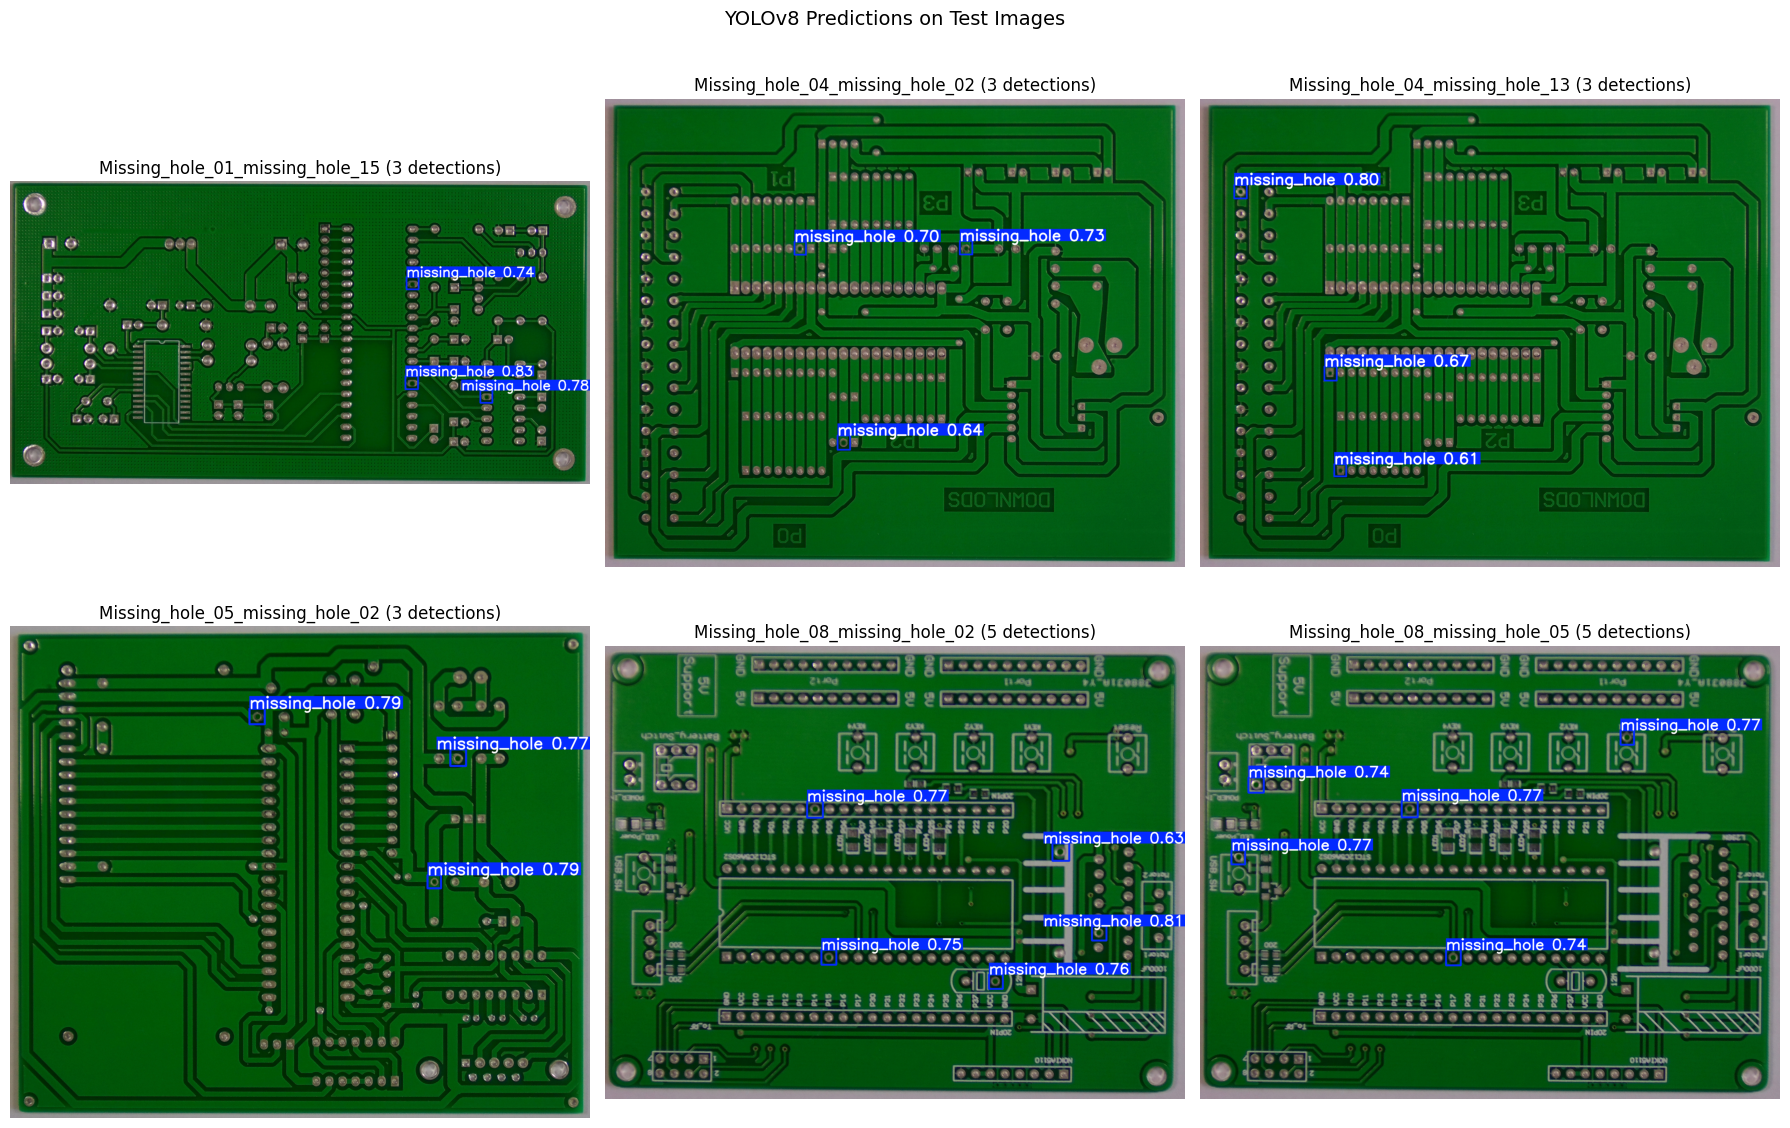

In [6]:
# Visualize predictions on test images
test_images_dir = Path("../data/pcb-yolo/images/test")
test_images = sorted(test_images_dir.glob("*"))[:6]

if best_model_path.exists() and test_images:
    best_model = YOLO(str(best_model_path))

    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    for ax, img_path in zip(axes.flat, test_images):
        results = best_model.predict(str(img_path), verbose=False)
        annotated = results[0].plot()
        annotated_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)
        ax.imshow(annotated_rgb)
        n_det = len(results[0].boxes)
        ax.set_title(f"{img_path.stem} ({n_det} detections)")
        ax.axis("off")

    plt.suptitle("YOLOv8 Predictions on Test Images", fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print("Model or test images not available")

## 6. Confusion Matrix & PR Curves

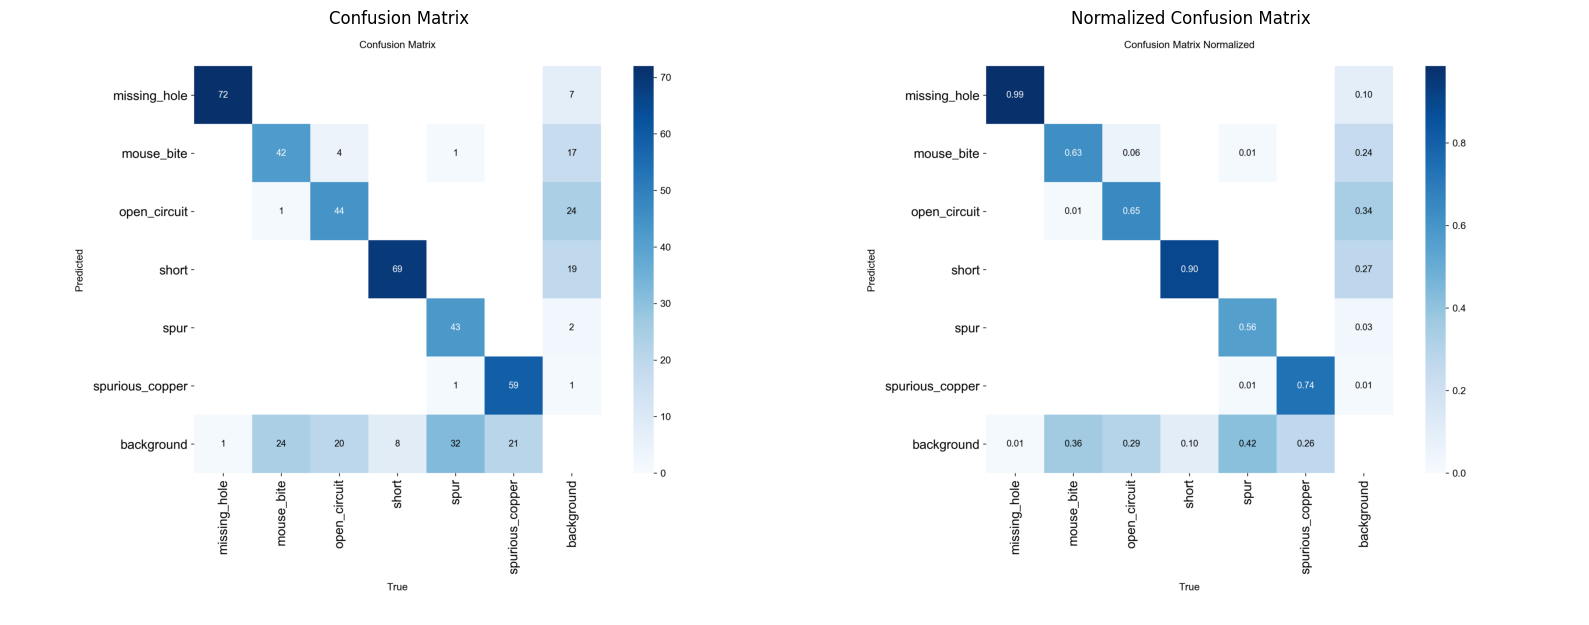

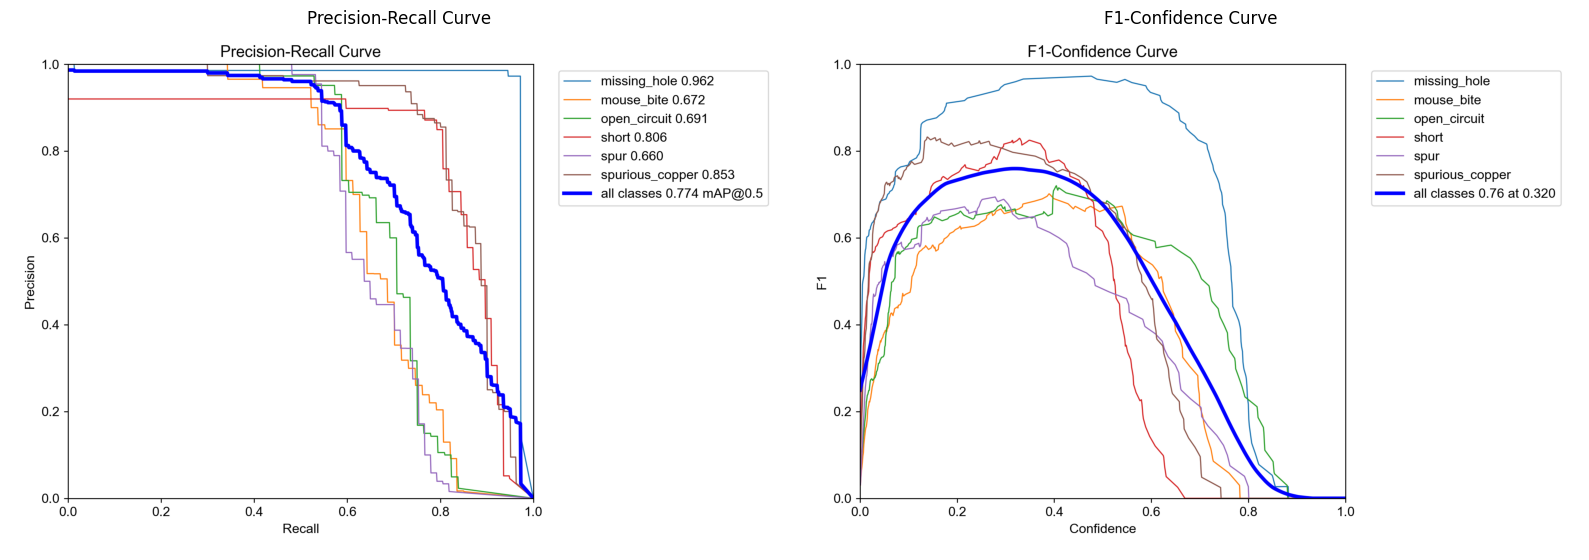

In [7]:
# Display confusion matrices and PR curves from validation
cm_path = PROJECT_DIR / "yolov8_pcb" / "confusion_matrix.png"
cm_norm_path = PROJECT_DIR / "yolov8_pcb" / "confusion_matrix_normalized.png"

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, path, title in [
    (axes[0], cm_path, "Confusion Matrix"),
    (axes[1], cm_norm_path, "Normalized Confusion Matrix"),
]:
    if path.exists():
        img = Image.open(path)
        ax.imshow(img)
        ax.set_title(title)
    else:
        ax.text(0.5, 0.5, f"Not found:\n{path.name}", ha="center", va="center")
    ax.axis("off")
plt.tight_layout()
plt.show()

# Display Precision-Recall curves
pr_curve_path = PROJECT_DIR / "yolov8_pcb" / "BoxPR_curve.png"
f1_curve_path = PROJECT_DIR / "yolov8_pcb" / "BoxF1_curve.png"
pr_paths = [(pr_curve_path, "Precision-Recall Curve"), (f1_curve_path, "F1-Confidence Curve")]
available_pr = [(p, t) for p, t in pr_paths if p.exists()]

if available_pr:
    fig, axes = plt.subplots(1, len(available_pr), figsize=(8 * len(available_pr), 6))
    if len(available_pr) == 1:
        axes = [axes]
    for ax, (path, title) in zip(axes, available_pr):
        img = Image.open(path)
        ax.imshow(img)
        ax.set_title(title)
        ax.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("PR/F1 curve images not found — they are generated during model.val()")

## 7. Save Best Model

Copy the best weights to the project `models/` directory for use in downstream notebooks (04-ResNet, 06-Comparison, 07-ONNX, 08-Flask).

In [8]:
# Save best model for downstream use
models_dir = Path("../models")
models_dir.mkdir(exist_ok=True)

if best_model_path.exists():
    dst = models_dir / "yolov8_best.pt"
    shutil.copy2(best_model_path, dst)
    print(f"Best model saved to {dst}")
    print(f"Model size: {dst.stat().st_size / 1024 / 1024:.1f} MB")
else:
    print("No best model to save — complete training first")

Best model saved to ../models/yolov8_best.pt
Model size: 6.0 MB
